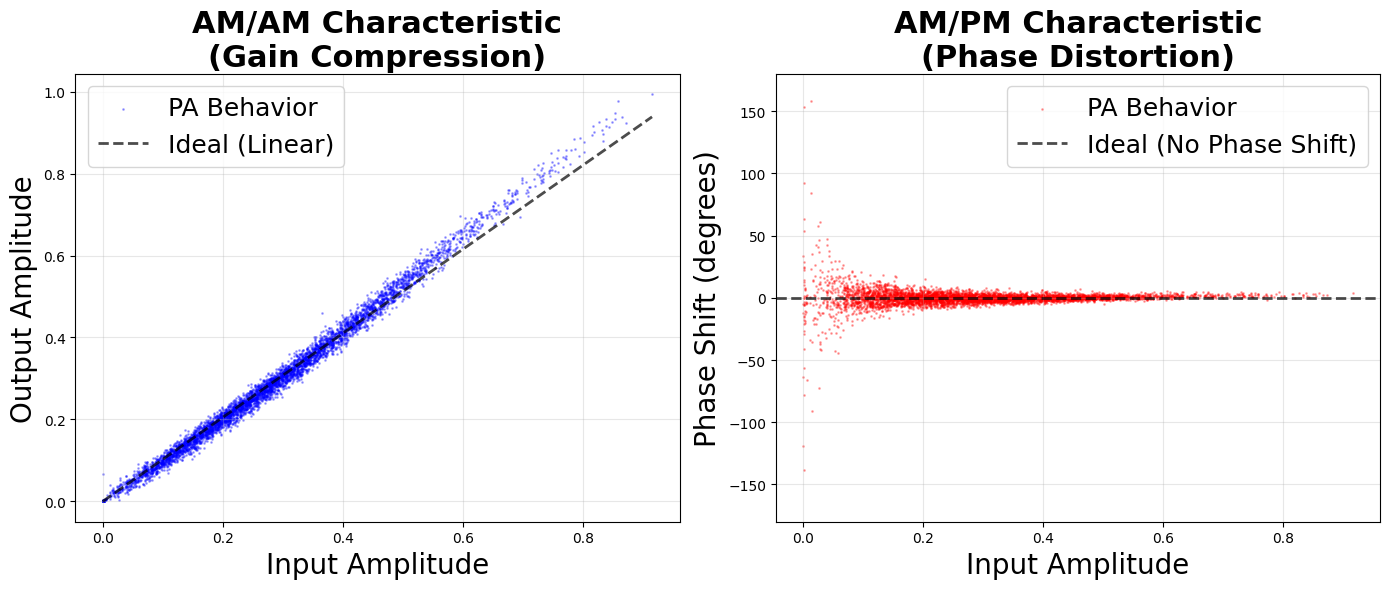


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9157
Output amplitude range: 0.0001 to 0.9934
Estimated small-signal gain: 1.0248
Phase distortion range: -209.73° to 158.56°
80000


In [1]:
from sparseDPD import DataManager, PNTDNN_NeuralNetwork, Volterra, LinearExperiment, AdaptivePruningExperiment

# Load the ideal predistorted signal, and plot
ideal_predistored_dataset = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='100M_9.5PAPR.mat')

ideal_predistored_dataset.plot_pa_characteristics()

print(len(ideal_predistored_dataset.input_data))

In [2]:
# Print Volterra Performance
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=15, dataset=ideal_predistored_dataset.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(ideal_predistored_dataset.test_dataset)} dB")

 Volterra NMSE: -38.83018925323994 dB


In [4]:
# Model the ideal predistorted (This will actually be modelled as a forward model)
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True)

# train this model
pntdnn_ideal_predistorted.get_best_model(
    num_epochs = 1000,
    training_dataset=ideal_predistored_dataset.training_dataset,
    validation_dataset=ideal_predistored_dataset.validation_dataset
)

# Save the model, so it can be used later
pntdnn_ideal_predistorted.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model.pt")


Using cuda device
Epoch  10/1000  Loss=9.4022e+01  Valid Loss=7.3373e+00  LR=1.00e-03  NMSE=-16.1075 dB
Epoch  20/1000  Loss=1.5302e+01  Valid Loss=1.2432e+00  LR=1.00e-03  NMSE=-23.8174 dB
Epoch  30/1000  Loss=6.3325e+00  Valid Loss=5.7517e-01  LR=1.00e-03  NMSE=-27.1649 dB
Epoch  40/1000  Loss=4.3503e+00  Valid Loss=4.0945e-01  LR=1.00e-03  NMSE=-28.6409 dB
Epoch  50/1000  Loss=3.1776e+00  Valid Loss=3.0112e-01  LR=1.00e-03  NMSE=-29.9754 dB
Epoch  60/1000  Loss=2.3224e+00  Valid Loss=2.2111e-01  LR=1.00e-03  NMSE=-31.3168 dB
Epoch  70/1000  Loss=1.7154e+00  Valid Loss=1.6472e-01  LR=1.00e-03  NMSE=-32.5955 dB
Epoch  80/1000  Loss=1.3107e+00  Valid Loss=1.2770e-01  LR=1.00e-03  NMSE=-33.7008 dB
Epoch  90/1000  Loss=1.0493e+00  Valid Loss=1.0235e-01  LR=1.00e-03  NMSE=-34.6619 dB
Epoch 100/1000  Loss=8.8159e-01  Valid Loss=8.5359e-02  LR=1.00e-03  NMSE=-35.4503 dB
Epoch 110/1000  Loss=7.6896e-01  Valid Loss=7.3492e-02  LR=1.00e-03  NMSE=-36.1005 dB
Epoch 120/1000  Loss=6.8914e-01  Val

Using cuda device

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 300 epochs...
Epoch  10/300  Loss=1.9381e-01  Valid Loss=1.7686e-02  LR=1.00e-03  NMSE=-42.2866 dB
Epoch  20/300  Loss=2.0146e-01  Valid Loss=1.8018e-02  LR=1.00e-03  NMSE=-42.2058 dB
Epoch  30/300  Loss=1.8999e-01  Valid Loss=1.7147e-02  LR=5.00e-04  NMSE=-42.4209 dB
Epoch  40/300  Loss=1.8929e-01  Valid Loss=1.7369e-02  LR=5.00e-04  NMSE=-42.3652 dB
Epoch  50/300  Loss=1.8600e-01  Valid Loss=1.7152e-02  LR=2.50e-04  NMSE=-42.4196 dB
Epoch  60/300  Loss=1.8868e-01  Valid Loss=1.7174e-02  LR=1.25e-04  NMSE=-42.4140 dB
Epoch  70/300  Loss=1.8448e-01  Valid Loss=1.7107e-02  LR=6.25e-05  NMSE=-42.4310 dB
Epoch  80/300  Loss=1.8367e-01  Valid Loss=1.7021e-02  LR=3.13e-05  NMSE=-42.4530 dB
Epoch  90/300  Loss=1.8345e-01  Valid Loss=1.6998e-02  LR=1.56e-05  NMSE=-42.4588 dB
Epoch 100/300  Loss=1.8344e-01  Valid Loss=1.7005e-02  LR=1.56e-05  NMSE=-42.4569 

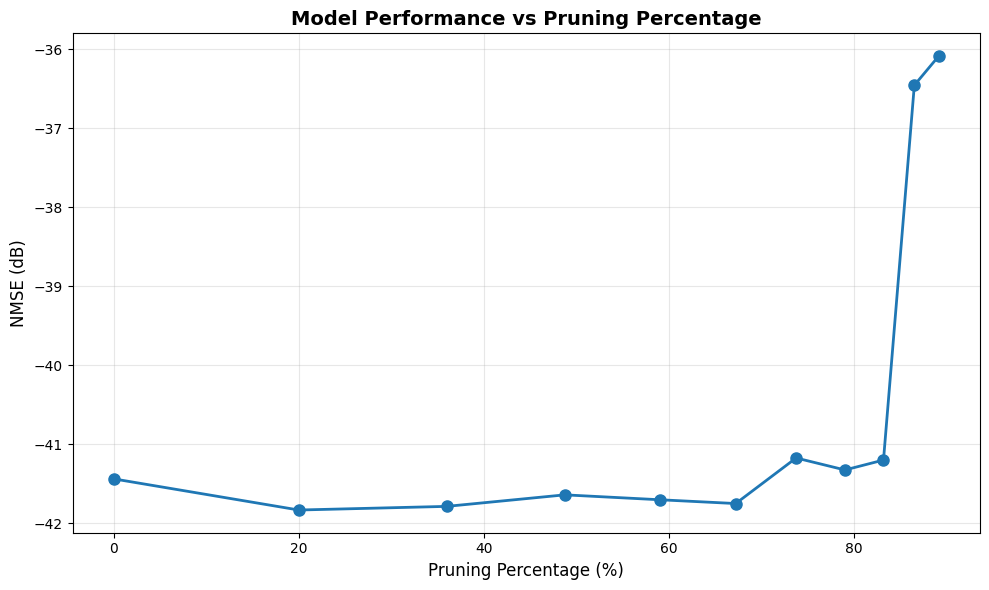

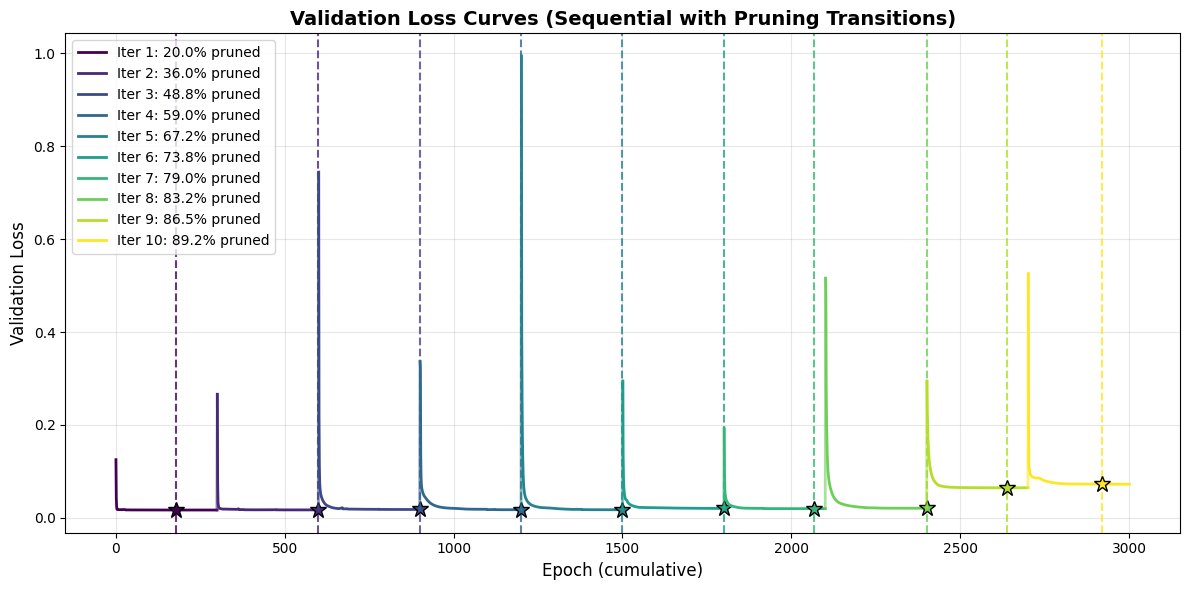

In [5]:
# Linearly prune the model
# Load the model
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

pntdnn_ideal_pruning_experiment = LinearExperiment(
    nn_model= pntdnn_ideal_predistorted,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=300,
    training_dataset=ideal_predistored_dataset.training_dataset,
    valid_dataset=ideal_predistored_dataset.validation_dataset,
    test_dataset=ideal_predistored_dataset.test_dataset,
    nmse_tolerance=-40
)
pntdnn_ideal_pruning_experiment.run()

# Save the best model
pntdnn_ideal_pruning_experiment.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")

Using cuda device
Baseline NMSE          : -41.4411 dB
Tolerance              : +1.44 dB
NMSE must stay below   : -40.0000 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 300 epochs...
Epoch  10/300  Loss=6.6078e-01  Valid Loss=6.1700e-02  LR=1.00e-03  NMSE=-36.8600 dB
Epoch  20/300  Loss=4.2388e-01  Valid Loss=4.0606e-02  LR=1.00e-03  NMSE=-38.6769 dB
Epoch  30/300  Loss=3.4357e-01  Valid Loss=3.2602e-02  LR=1.00e-03  NMSE=-39.6304 dB
Epoch  40/300  Loss=2.9721e-01  Valid Loss=2.8445e-02  LR=1.00e-03  NMSE=-40.2227 dB
Epoch  50/300  Loss=2.7214e-01  Valid Loss=2.6651e-02  LR=1.00e-03  NMSE=-40.5056 dB
Epoch  60/300  Loss=2.5545e-01  Valid Loss=2.5157e-02  LR=1.00e-03  NMSE=-40.7562 dB
Epoch  70/300  Loss=2.4463e-01  Valid Loss=2.4128e-02  LR=1.00e-03  NMSE=-40.9376 dB
Epoch  80/300  Loss=2.3753e-01  Valid Loss=2

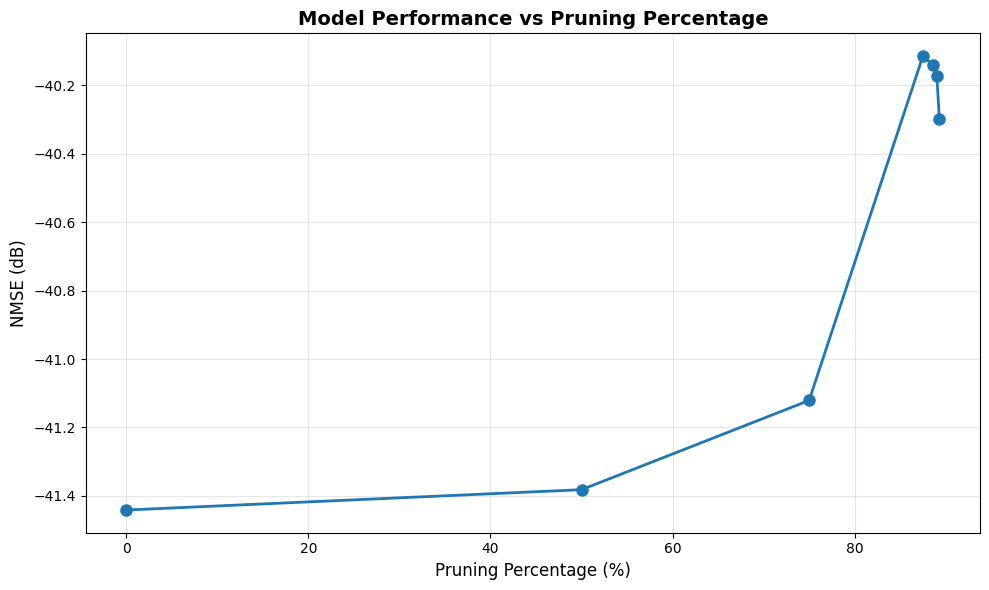

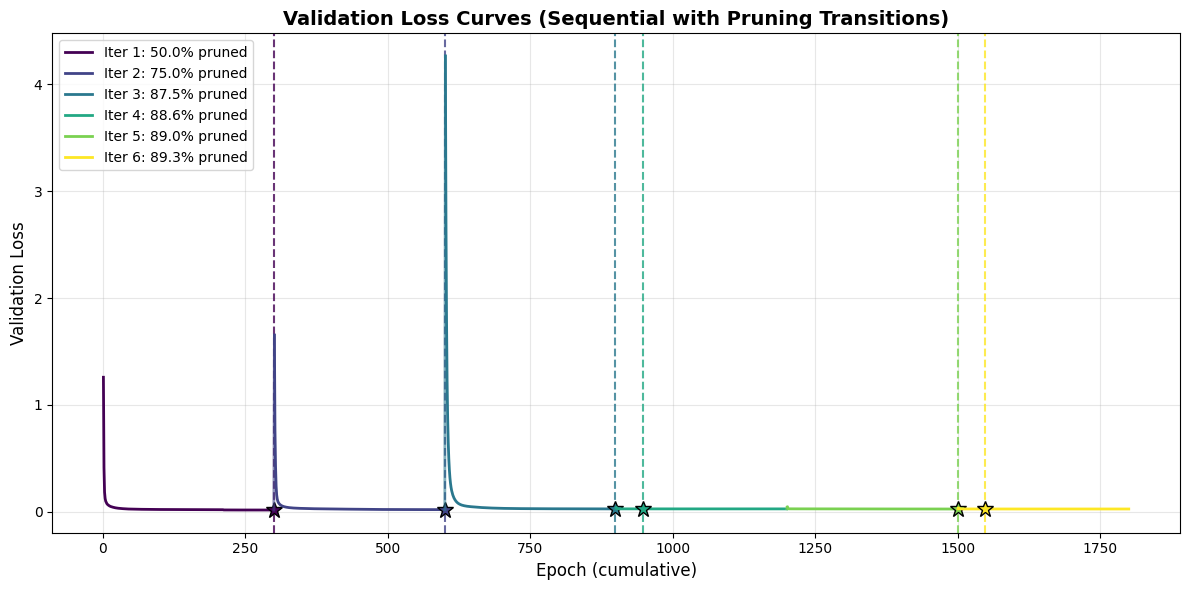

In [6]:
# Use adaptive pruning
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

adaptive_pruning_experiment_PNTDNN = AdaptivePruningExperiment(
    nn_model=pntdnn_ideal_predistorted,
    retrain_epochs= 300,
    training_dataset = ideal_predistored_dataset.training_dataset,
    valid_dataset = ideal_predistored_dataset.validation_dataset,
    test_dataset = ideal_predistored_dataset.test_dataset,
    nmse_threshold = -40,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PNTDNN.run()

# Save the best model
adaptive_pruning_experiment_PNTDNN.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")

In [7]:
# make .mat files for the best models, so they can be used in the future for physical testing
import scipy.io

num_memory_levels = 15
# Load original, adaptive and fixed pruning models
adaptive_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")
fixed_percent_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")
original_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

# Get the full input signal
full_input = ideal_predistored_dataset.input_data

# Generate outputs for each model
print("Generating outputs for each model...")
adaptive_output = adaptive_model.generate_model_output(full_input)
fixed_output = fixed_percent_model.generate_model_output(full_input)
original_output = original_model.generate_model_output(full_input)

# Save to .mat files with 'x' (input) and 'u' (output) naming convention
print("Saving .mat files...")
scipy.io.savemat('adaptive_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': adaptive_output})
scipy.io.savemat('fixed_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': fixed_output})
scipy.io.savemat('original_model_output.mat', {'x1': full_input[num_memory_levels:], 'u': original_output})

print("✓ Saved adaptive_pruned_output.mat")
print("✓ Saved fixed_pruned_output.mat")
print("✓ Saved original_model_output.mat")

Using cuda device
Using cuda device
Using cuda device
Generating outputs for each model...
Saving .mat files...
✓ Saved adaptive_pruned_output.mat
✓ Saved fixed_pruned_output.mat
✓ Saved original_model_output.mat


In [8]:
# Optionally save Volterra model output as well
volterra_output = volterra_forward_model.generate_model_output(full_input)
scipy.io.savemat('volterra_output.mat', {'x1': full_input[num_memory_levels:], 'u': volterra_output})
print("✓ Saved volterra_output.mat")

✓ Saved volterra_output.mat


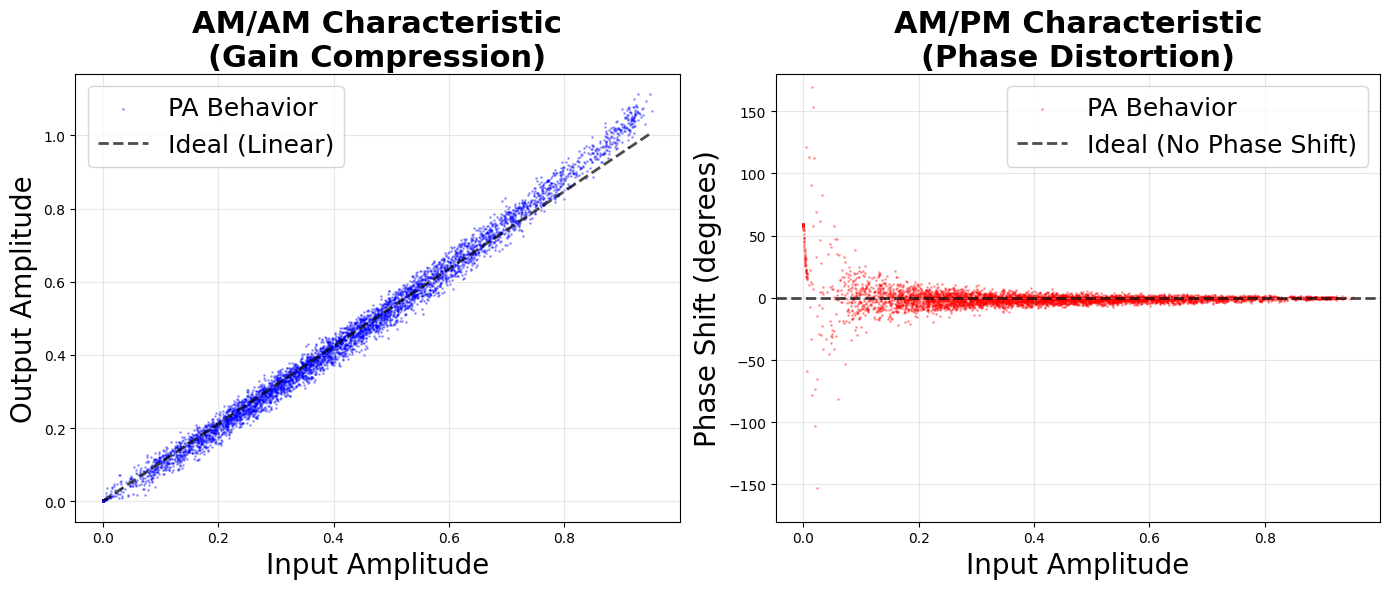


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9520
Output amplitude range: 0.0024 to 1.1121
Estimated small-signal gain: 1.0588
Phase distortion range: -152.59° to 169.79°


In [ ]:
test = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='fixed_pruned_output.mat')

test.plot_pa_characteristics()